Sample Dataset:
   CustomerID  Age  Annual Income (k$)  Spending Score (1-100)
0           1   56                  84                      61
1           2   69                  86                      48
2           3   46                  41                      19
3           4   32                  23                       4
4           5   60                  76                      35


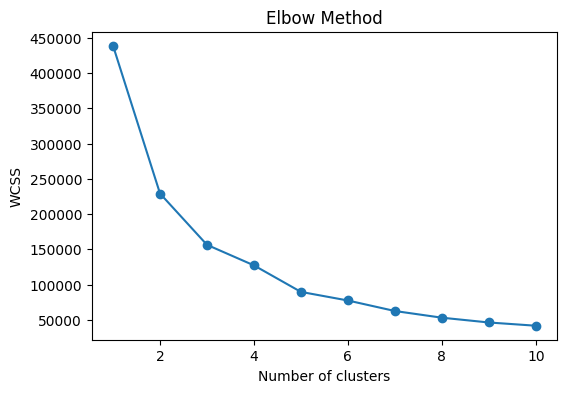

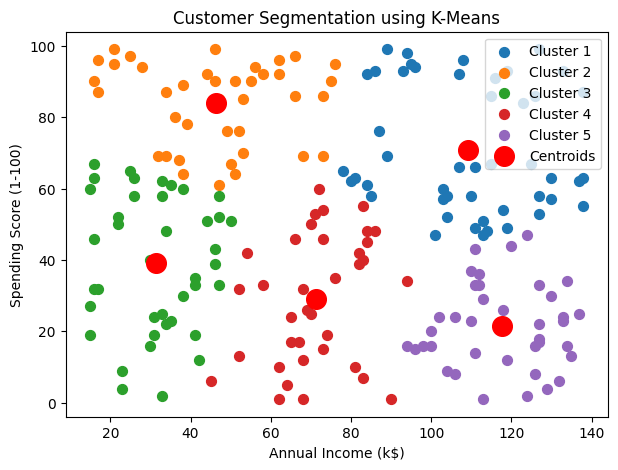


Customer Group Description:
Cluster 1: Low income – Low spending → Budget customers
Cluster 2: Low income – High spending → Offer-sensitive customers
Cluster 3: Medium income – Medium spending → Average customers
Cluster 4: High income – Low spending → Careful premium customers
Cluster 5: High income – High spending → Target customers

Dataset with Cluster Labels:
   CustomerID  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0           1   56                  84                      61        0
1           2   69                  86                      48        3
2           3   46                  41                      19        2
3           4   32                  23                       4        2
4           5   60                  76                      35        3


In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Step 2: Create dataset
np.random.seed(42)

data = pd.DataFrame({
    "CustomerID": range(1, 201),
    "Age": np.random.randint(18, 70, 200),
    "Annual Income (k$)": np.random.randint(15, 140, 200),
    "Spending Score (1-100)": np.random.randint(1, 100, 200)
})

print("Sample Dataset:")
print(data.head())

# Step 3: Select features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Step 4: Elbow Method
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# Step 5: Apply K-Means clustering
kmeans = KMeans(n_clusters=5, random_state=0)
clusters = kmeans.fit_predict(X)

data['Cluster'] = clusters

# Step 6: Visualize clusters
plt.figure(figsize=(7,5))

for i in range(5):
    plt.scatter(
        X.iloc[clusters == i, 0],
        X.iloc[clusters == i, 1],
        s=50,
        label=f'Cluster {i+1}'
    )

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=200,
    c='red',
    label='Centroids'
)

plt.title('Customer Segmentation using K-Means')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

# Step 7: Print cluster descriptions
print("\nCustomer Group Description:")
print("Cluster 1: Low income – Low spending → Budget customers")
print("Cluster 2: Low income – High spending → Offer-sensitive customers")
print("Cluster 3: Medium income – Medium spending → Average customers")
print("Cluster 4: High income – Low spending → Careful premium customers")
print("Cluster 5: High income – High spending → Target customers")

# Step 8: Show clustered dataset
print("\nDataset with Cluster Labels:")
print(data.head())